# Week 06: Analyzing Data

In this notebook we'll explore two ways for getting more information from our data: visually and numerically.

Let's download the [Spotify Tracks](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) dataset to see what this means.

In [9]:
!wget -q https://raw.githubusercontent.com/PSAM-5005-2026S-A/5005-utils/refs/heads/main/datasets/csv/spotify_tracks.csv -P ./data
!wget -q https://raw.githubusercontent.com/PSAM-5005-2026S-A/5005-utils/refs/heads/main/datasets/csv/wines.csv -P ./data
!wget -q https://raw.githubusercontent.com/PSAM-5005-2026S-A/5005-utils/refs/heads/main/datasets/json/ansur.json -P ./data

Let's import some libraries.

In [10]:
import csv
import json

import pandas as pd
import matplotlib.pyplot as plt

And now we can load our data from the file into a `Python` variable.

In [11]:
# TODO: open csv file
csvfile = open("./data/spotify_tracks.csv")
csvreader = csv.reader(csvfile)
spotify = list(csvreader)

len (spotify)

114001

In [12]:
len (spotify)
spotify [:2]

[['',
  'track_id',
  'artists',
  'album_name',
  'track_name',
  'popularity',
  'duration_ms',
  'explicit',
  'danceability',
  'energy',
  'key',
  'loudness',
  'mode',
  'speechiness',
  'acousticness',
  'instrumentalness',
  'liveness',
  'valence',
  'tempo',
  'time_signature',
  'track_genre'],
 ['0',
  '5SuOikwiRyPMVoIQDJUgSV',
  'Gen Hoshino',
  'Comedy',
  'Comedy',
  '73',
  '230666',
  'False',
  '0.676',
  '0.461',
  '1',
  '-6.746',
  '0',
  '0.143',
  '0.0322',
  '1.01e-06',
  '0.358',
  '0.715',
  '87.917',
  '4',
  'acoustic']]

## Some Basic Information

Like we've done before:
- How many items are in our dataset ?
- What are the features ?
- How are they represented ?

In [13]:
# TODO: get some basic info about the dataset

# how many songs 
print (len(spotify))

# how many feauture 
print (len(spotify[0]))

# first 10 feauture 
print (len(spotify[0][:10]))

# first 10 feauture of first 2 songs
print (len(spotify[1][:10]))
print (len(spotify[2][:10]))

114001
21
10
10
10


## Some Stats

Extract some features and calculate:
- min/max/average song length
- min/max/average song popularity

We can write a function that generalizes this process: given a csv dataset and column name, return all values from that column.

But we can also just do this with two for loops.

In [14]:
# TODO: (optional)
#       write a function extract_vals(csvlist, col) that
#       receives csv list of lists and a property name and
#       returns list with all values associated with that property

# TODO: extract song lengths and calculate min/max/avg

all_lengths = []
all_pop =[]
for t in spotify[1:]:
  all_lengths.append(float(t[6]))
  all_pop.append(float(t[5]))

print(len(all_lengths))
print (all_lengths[:5])

print(all_pop)
print(all_pop[:5])



# TODO: extract song popularity scores and calculate min/max/avg

114000
[230666.0, 149610.0, 210826.0, 201933.0, 198853.0]
[73.0, 55.0, 57.0, 71.0, 82.0, 58.0, 74.0, 80.0, 74.0, 56.0, 74.0, 69.0, 52.0, 62.0, 56.0, 58.0, 56.0, 54.0, 68.0, 67.0, 75.0, 63.0, 70.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 46.0, 61.0, 60.0, 68.0, 52.0, 62.0, 51.0, 0.0, 67.0, 57.0, 75.0, 62.0, 66.0, 64.0, 62.0, 58.0, 65.0, 67.0, 65.0, 44.0, 55.0, 70.0, 57.0, 56.0, 56.0, 67.0, 62.0, 45.0, 64.0, 65.0, 0.0, 0.0, 68.0, 0.0, 0.0, 61.0, 70.0, 0.0, 0.0, 62.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 58.0, 50.0, 59.0, 57.0, 60.0, 61.0, 49.0, 55.0, 51.0, 46.0, 57.0, 58.0, 51.0, 63.0, 53.0, 60.0, 47.0, 60.0, 66.0, 67.0, 43.0, 54.0, 60.0, 49.0, 57.0, 42.0, 67.0, 61.0, 71.0, 49.0, 61.0, 61.0, 20.0, 22.0, 35.0, 60.0, 59.0, 73.0, 22.0, 19.0, 24.0, 57.0, 35.0, 20.0, 18.0, 19.0, 23.0, 19.0, 18.0, 65.0, 55.0, 47.0, 56.0, 53.0, 49.0, 51.0, 53.0, 66.0, 56.0, 47.0, 51.0, 55.0, 60.0, 40.0, 5

## Plots

The min/max/average values of a feature certainly are important, but it doesn't show us the whole picture of what's happening with our values, and how they might be related or show trends.

One way we can get to know our data better is by visualizing it in plots and graphs.

We'll use the `pyplot` library to plot some simple graphs to see exactly what our features look like.

[`PyPlot` Documentation](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html)

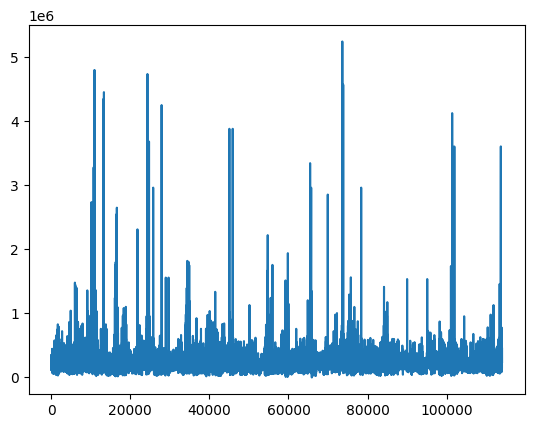

In [17]:
# Plotting our duration feature is not hard once we've extracted the values onto a separate list

plt.plot(all_lengths)
plt.show()

# the x-axis are the song row numbers, in the order of the original csv file
# the y-axis is the duration of each song in millisecond.

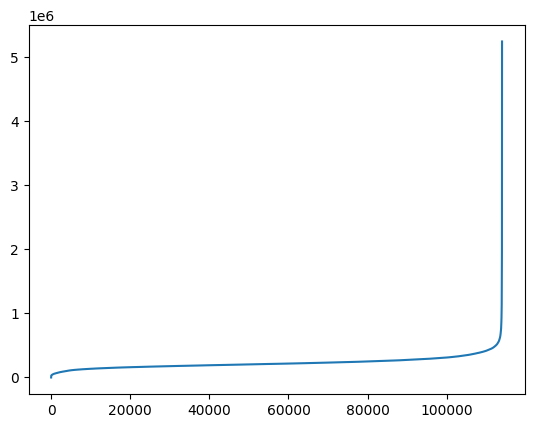

In [18]:
plt.plot(sorted(all_lengths))
plt.show()



### The `plot()` function

has ~~some~~ lots of options...

[Documentation](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.plot.html)

Adjusting some of these can help improve the legibility of our graph.

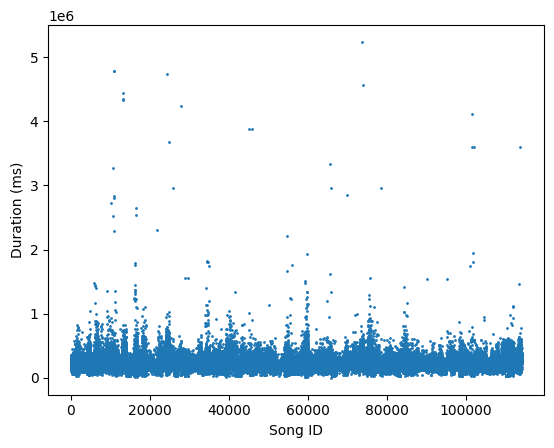

In [19]:
plt.plot(all_lengths, linestyle="", marker="o", markersize=1)
plt.xlabel("Song ID")
plt.ylabel("Duration (ms)")
plt.show()

We can add the average value to the graph by creating two points and connecting them with a line.

The first parameter to `plot()` specifies the $x$ values for our $2$ points, and the second parameters specifies their $y$ locations.

In [25]:
lenght_avg = sum(all_lengths) / len(all_lengths)

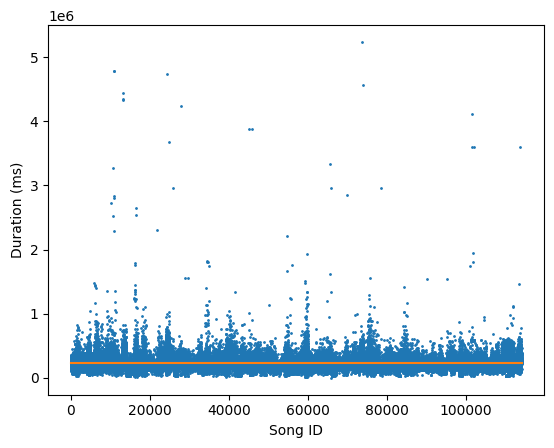

In [26]:
plt.plot(all_lengths, linestyle="", marker="o", markersize=1)
plt.plot([0, len(all_lengths)], [lenght_avg, lenght_avg])
plt.xlabel("Song ID")
plt.ylabel("Duration (ms)")
plt.show()

### The `hist()` function

The `plot()` function helps us see where each of our songs are situated in relation to a feature.

If we want to get some more aggregate information about our dataset as a whole, we can use the `hist()` function to plot histograms and see how the different values of our feature are distributed (if some are more likely than others).

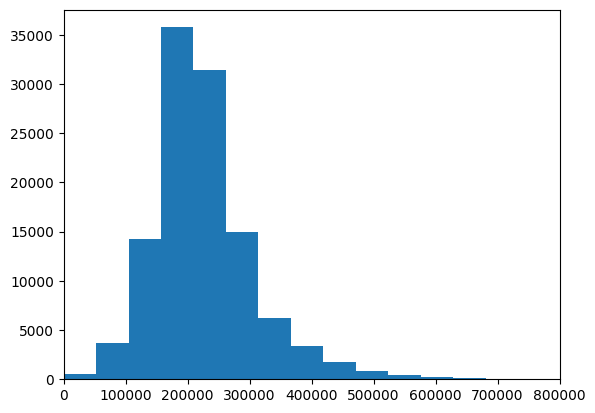

In [27]:
plt.hist(all_lengths, bins=100)
plt.xlim(0, 0.8 * 1_000_000)
plt.show()

### Repeat for the `popularity` feature

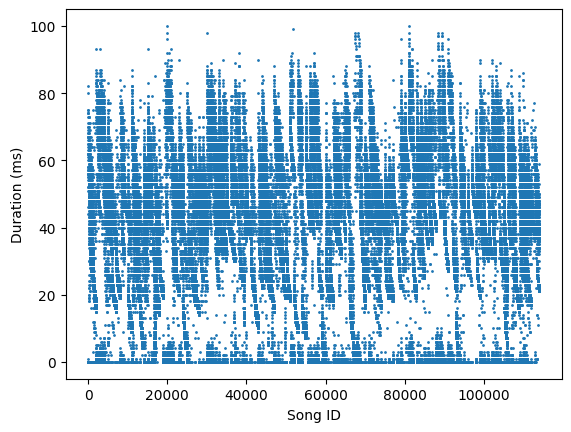

In [28]:
# TODO: Plot the scatter points and the histogram for the popularity feature

plt.plot(all_pop, linestyle="", marker="o", markersize=1)
plt.xlabel("Song ID")
plt.ylabel("Duration (ms)")
plt.show()

In [29]:
pop_avg = sum(all_pop) / len(all_pop)

### And other features

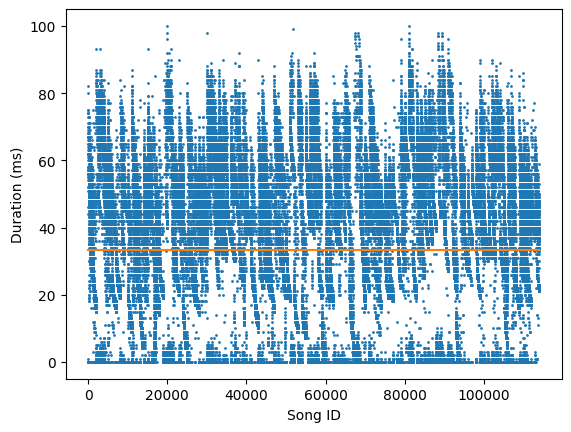

In [32]:
# TODO: extract and plot other numerical values from dataset, like:
#       danceability, energy, loudness

plt.plot(all_pop, linestyle="", marker="o", markersize=1)
plt.plot([0, len(all_pop)], [pop_avg, pop_avg])
plt.xlabel("Song ID")
plt.ylabel("Duration (ms)")
plt.show()


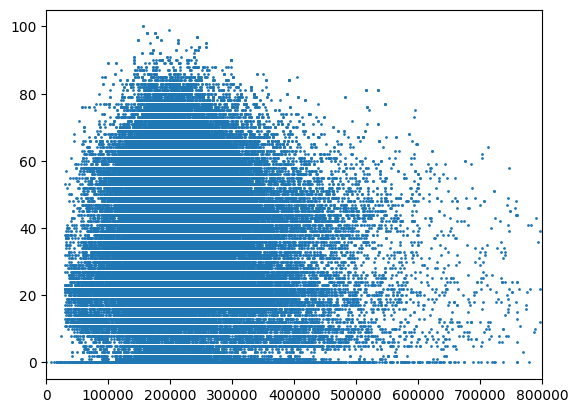

In [35]:
plt.plot(all_lengths, all_pop, linestyle="", marker="o", markersize=1)
plt.xlim(0,0.8 * 1_000_000)
plt.show()

## Relationship between features

Are longer songs more popular ? Are shorter songs more popular ?

We can use the `plot()` function, and instead of plotting a single feature, give it $2$ features, to see our `popularity` and `duration` data on the same graph at the same time.

In [ ]:
plt.plot(dur_vals, pop_vals, linestyle="", marker="o", markersize=1, alpha=0.2)
plt.show()

Each dot still represents a song, but now it's horizontal position is determined by its `duration` and its vertical position by its `popularity`.

This helps us see trends.

In the above graph, we have a lot of durations that go way over to the right side of the graph, skewing our plot.

Let's "zoom" in on `duration` less than $10$ minutes (or, $600\text{,}000$ milliseconds.

In [ ]:
plt.plot(dur_vals, pop_vals, linestyle="", marker="o", markersize=1, alpha=0.2)
plt.xlim((0, 10*60*1000))
plt.show()

We can also look at histograms using $2$ features.

This tells us how common a certain pair of values is.

In [ ]:
plt.hist2d(dur_vals, pop_vals, bins=64)
# plt.xlim((0, 600000))
plt.show()

### Repeat !

Take a look at some $2D$ plots using other pairs of features.

In [ ]:
# TODO: plot pairs of values to look for relationships between variables

### 3D plots

And, we can plot data using $3$ features at the same time.

### More plot possibilities

lines, scatter, histogram, bars, pie, polar, 3D, etc

https://matplotlib.org/stable/gallery/index.html

## Simple Stats with Pandas

Plotting our data is a great way to see what's in our dataset.

Sometimes it helps to filter the data before plotting it, and other times it's best to calculate some of the patterns and trends numerically, instead of relying on visual analysis.

In both of these cases, it helps to use `pandas`, a library that gives us a more complete set of tools for analyzing, processing and manipulating spreadsheet-like data.

Let's load the csv file into a `pandas` `DataFrame`:

In [37]:
spotify_df = pd.read_csv("./data/spotify_tracks.csv")
spotify_df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


Cool. It looks like a spreadsheet, but it has super powers.

### Column indexing

For starters, we don't have to use for loops and if statements to separate columns from our dataset; we can just index by column name.

We can get all of the `duration` values with just `spotify_df["duration_ms"]`.

Try it out:

In [38]:
spotify_df["duration_ms"]

0         230666
1         149610
2         210826
3         201933
4         198853
           ...  
113995    384999
113996    385000
113997    271466
113998    283893
113999    241826
Name: duration_ms, Length: 114000, dtype: int64

### Multiple Columns

We can even index multiple columns at a time to get a subset of our data (note the double brackets):

In [ ]:
spotify_df[["duration_ms", "popularity", "danceability"]]

### Conditional indexing

We can also perform filtering by passing boolean expressions inside the brackets.

This gets all rows where the `duration` is between less than $5$ minutes:

`spotify_df[spotify_df["duration_ms] < 300_000]`

In [ ]:
spotify_df[spotify_df["duration_ms"] < 300_000]

### Whoa

This is huge.

Let's revisit some of the questions from Homework 02 and try to do them with `DataFrame`:

In [ ]:
wines_df = pd.read_csv("./data/wines.csv")
wines_df

In [ ]:
# What's the average rating for California wines ?
# (we can filter and then index the filtered data by column)

ca_points = wines_df[wines_df["province"] == "California"]["points"]
sum(ca_points) / len(ca_points)

# OR:
# wines_df[wines_df["province"] == "California"]["points"].mean()

In [ ]:
# What's the most expensive wine from Spain ?
# (filter and sort by column, then select the first row with iloc[0])

wines_df[wines_df["country"] == "Spain"].sort_values("price", ascending=False).iloc[0]


In [ ]:
# Where's the worse wine in the US from ?
# (filter by country, sort by points, then get designation, province, region and winery columns for first row)

wines_df[wines_df["country"] == "US"].sort_values("points").iloc[0][["designation", "province", "region", "winery"]]

In [ ]:
# Which country between spain/us/france has highest average price ?
# (group by country, select column, get average/mean, select countries, sort)

wines_df.groupby("country")["price"].mean()[["US", "Spain", "France"]].sort_values()

In [ ]:
# Which country between spain/us/france has highest average quality points ?
# (group by country, select column, get average/mean, select countries, sort)

wines_df.groupby("country")["points"].mean()[["US", "Spain", "France"]].sort_values()

### That last question, finally:

*Are the best wines also the most expensive ?*

We can plot wine `prices` and `points` now to get a more accurate answer to this question.

In [ ]:
plt.plot(wines_df["points"], wines_df["price"], linestyle="", marker="o", alpha=0.1)
plt.ylim([0, 150])
plt.show()

### Hmmm...

Kind of...

Maybe the most expensive wine is not the highest rated, but looking at all wines at the same time, it looks like the prices do go up as points increase.

We can measure how much. There's a statistical property that measures how much two features change together: correlation.

If two features have correlation close to $1$ or $-1$, there's a strong relationship between them.

If the correlation is close to $0$, then one feature doesn't tell us anything about the other.

It's common to get values in between $0$ and $1$... 

In `pandas` we can do this with:

`wines_df[["price", "points"]].corr()`

In [ ]:
wines_df[["price", "points"]].corr()

## Back to Spotify

We can do some similar filtering.

Considering only songs that are less than $10$ minutes, are shorter songs more popular?

In [ ]:
lt10m = spotify_df[spotify_df["duration_ms"] < 600000]

plt.plot(lt10m["duration_ms"], lt10m["popularity"], linestyle="", marker="o", alpha=0.2, markersize=2)
plt.show()

In [ ]:
# Hard to tell from graph, maybe use correlation

lt10m[["duration_ms", "popularity"]].corr()

### Are danceable songs more popular ?

## Questions

- Who's the artist with the most tracks ?
- Who wrote the longest song with a popularity score greater than $50$ ?
- How long is it ?
- Are "explicit" songs more popular ?
- Which of the following is more popular: _reggaeton_, _sertanejo_, _pagode_, _samba_ or _salsa_ ?
- Which is louder ?